<a href="https://colab.research.google.com/github/cs23f011-lang/CSL701-Roll_No_CS16_Machine-Learning-La/blob/main/Experiment_2_Simple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Anisha Atamaram Gawade Roll No:CS16 Batch :CS1

Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

Step 2: Load Dataset

In [38]:
from google.colab import files

uploaded = files.upload()

Saving auto-mpg.csv to auto-mpg (2).csv


In [54]:
df = pd.read_csv("auto-mpg.csv")

Step 3: Dataset Information

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [56]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [ ]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


Step 4: Data Cleaning

In [ ]:
# Keep only required columns
df = df[['horsepower', 'mpg']]

# Remove missing values
df.dropna(inplace=True)

df.head()

,horsepower,mpg
0,130,18.0
1,165,15.0
2,150,18.0
3,150,16.0
4,140,17.0


Step 5: Exploratory Data Analysis

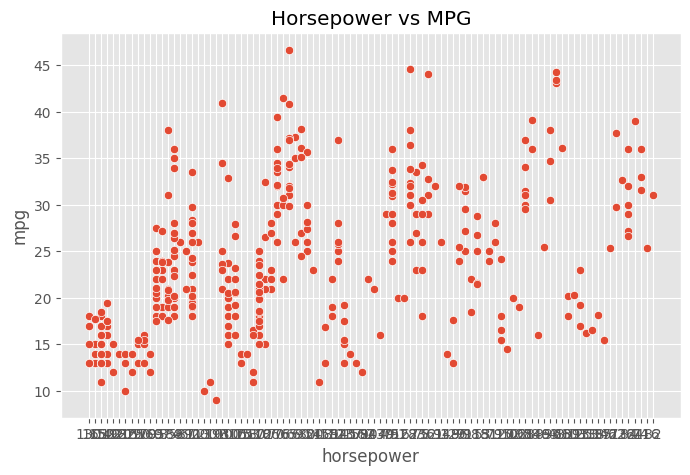

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='horsepower',
                y='mpg',
                data=df)

plt.title("Horsepower vs MPG")
plt.show()

In [60]:
import numpy as np

# Replace '?' with NaN
df['horsepower'] = df['horsepower'].replace('?', np.nan)

# Convert to numeric
df['horsepower'] = pd.to_numeric(df['horsepower'])

# Drop rows with missing values
df.dropna(subset=['horsepower', 'mpg'], inplace=True)

In [61]:
corr = df['horsepower'].corr(df['mpg'])

print("Correlation =", corr)

Correlation = -0.7784267838977756


Step 6: Prepare Data for OLS

In [64]:
X = df['horsepower'].values
y = df['mpg'].values

# Add bias column
X_bias = np.column_stack((np.ones(len(X)), X))

X_bias[:5]

array([[  1., 130.],
       [  1., 165.],
       [  1., 150.],
       [  1., 150.],
       [  1., 140.]])

Step 7: Compute OLS Weights Manually

In [65]:
w = np.linalg.inv(X_bias.T @ X_bias) @ (X_bias.T @ y)

print("Intercept =", w[0])
print("Slope =", w[1])

Intercept = 39.93586102117056
Slope = -0.1578447333536543


Step 8: Prediction

In [66]:
y_pred = X_bias @ w

y_pred[:10]

array([19.41604569, 13.89148002, 16.25915102, 16.25915102, 17.83759835,
        8.68260382,  5.21001968,  5.99924335,  4.42079602,  9.94536168])

Step 9: Residuals

In [67]:
residuals = y - y_pred

residuals[:10]

array([-1.41604569,  1.10851998,  1.74084898, -0.25915102, -0.83759835,
        6.31739618,  8.78998032,  8.00075665,  9.57920398,  5.05463832])

Step 10: Performance Metrics

In [68]:
#SSE
SSE = np.sum((y - y_pred)**2)

print("SSE =", SSE)

SSE = 9385.915871932419


In [69]:
#MSE
MSE = np.mean((y - y_pred)**2)

print("MSE =", MSE)

MSE = 23.943662938603108


In [70]:
#R² Score
SS_total = np.sum((y - np.mean(y))**2)

R2 = 1 - (SSE / SS_total)

print("R² =", R2)

R² = 0.6059482578894348


Step 11: Regression Line

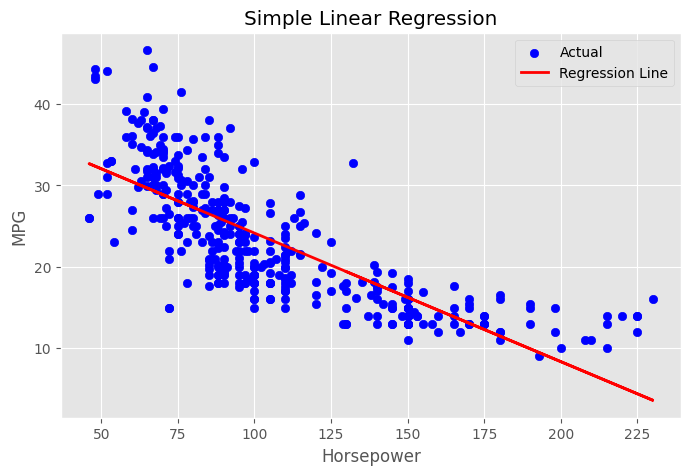

In [71]:
plt.figure(figsize=(8,5))

plt.scatter(X, y, color='blue', label='Actual')

plt.plot(X,
         y_pred,
         color='red',
         linewidth=2,
         label='Regression Line')

plt.xlabel("Horsepower")

plt.ylabel("MPG")

plt.title("Simple Linear Regression")

plt.legend()

plt.show()

Step 12: Residual Plot

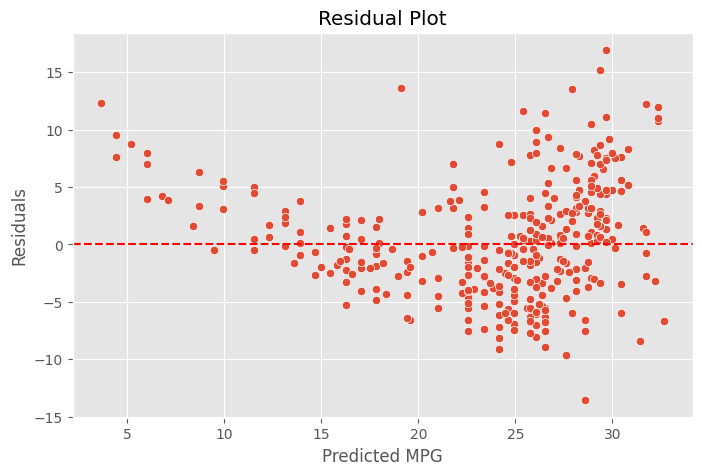

In [72]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=y_pred,
                y=residuals)

plt.axhline(0,
            color='red',
            linestyle='--')

plt.xlabel("Predicted MPG")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

Step 13: Final Model

In [73]:
print(f"Regression Equation:")

print(f"MPG = {w[0]:.3f} + ({w[1]:.3f}) × Horsepower")

Regression Equation:
MPG = 39.936 + (-0.158) × Horsepower
